# Question 10: Boston Dataset - Gaussian Kernel Smoother with 22-Fold Cross-Validation
## Advanced Regression - Problem Set 4

This notebook applies Gaussian Kernel smoothers to the Boston dataset using 22-fold cross-validation to find the optimal bandwidth (σ).
The response variable is **medv** (Median home value in $1000s) and the predictor is **lstat** (% lower status population).

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Step 1: Load the Boston Dataset from CSV

In [4]:
# Load Boston dataset from CSV file
boston_df = pd.read_csv('Boston.csv')

# Extract predictor (lstat) and response (medv)
# lstat: % lower status population
# medv: Median home value in $1000s
X_full = boston_df['lstat'].values
Y_full = boston_df['medv'].values

print(f"Dataset loaded successfully!")
print(f"Dataset shape: {len(X_full)} observations")
print(f"\nColumns in dataset: {boston_df.columns.tolist()}")
print(f"\nX (lstat - % lower status) range: [{X_full.min():.2f}, {X_full.max():.2f}]")
print(f"Y (medv - Median home value in $1000s) range: [{Y_full.min():.2f}, {Y_full.max():.2f}]")
print(f"\nFirst 10 observations:")
print(boston_df[['lstat', 'medv']].head(10))
print(f"\nDataset statistics:")
print(boston_df[['lstat', 'medv']].describe())

Dataset loaded successfully!
Dataset shape: 506 observations

Columns in dataset: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat', 'medv']

X (lstat - % lower status) range: [1.73, 37.97]
Y (medv - Median home value in $1000s) range: [5.00, 50.00]

First 10 observations:
   lstat  medv
0   4.98  24.0
1   9.14  21.6
2   4.03  34.7
3   2.94  33.4
4   5.33  36.2
5   5.21  28.7
6  12.43  22.9
7  19.15  27.1
8  29.93  16.5
9  17.10  18.9

Dataset statistics:
            lstat        medv
count  506.000000  506.000000
mean    12.653063   22.532806
std      7.141062    9.197104
min      1.730000    5.000000
25%      6.950000   17.025000
50%     11.360000   21.200000
75%     16.955000   25.000000
max     37.970000   50.000000


## Step 2: Create 22 Strata of Equal Size

In [5]:
# Divide observations into 22 strata of equal size
n_strata = 22
n_samples = len(X_full)
stratum_size = n_samples // n_strata

print(f"Total observations: {n_samples}")
print(f"Number of strata: {n_strata}")
print(f"Stratum size: {stratum_size} (with {n_samples % n_strata} extra samples)")

# Create stratified indices by sorting based on X values
sorted_indices = np.argsort(X_full)
X_sorted = X_full[sorted_indices]
Y_sorted = Y_full[sorted_indices]
indices_sorted = sorted_indices.copy()

# Create strata
strata = []
for i in range(n_strata):
    start_idx = i * stratum_size
    end_idx = start_idx + stratum_size if i < n_strata - 1 else n_samples
    strata.append(indices_sorted[start_idx:end_idx])

print(f"\nStratum sizes: {[len(s) for s in strata]}")
print(f"\nStratum ranges (lstat values):")
for i, stratum in enumerate(strata[:5]):
    lstat_values = X_full[stratum]
    print(f"  Stratum {i+1}: lstat range [{lstat_values.min():.2f}, {lstat_values.max():.2f}]")
print(f"  ...")

Total observations: 506
Number of strata: 22
Stratum size: 23 (with 0 extra samples)

Stratum sizes: [23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23]

Stratum ranges (lstat values):
  Stratum 1: lstat range [1.73, 3.56]
  Stratum 2: lstat range [3.57, 4.56]
  Stratum 3: lstat range [4.59, 5.21]
  Stratum 4: lstat range [5.25, 5.98]
  Stratum 5: lstat range [5.98, 6.62]
  ...


## Step 3: Define Gaussian Kernel Smoother

In [6]:
def gaussian_kernel(x, x_i, sigma):
    """
    Gaussian (RBF) kernel: K(u) = exp(-u^2 / 2)
    where u = (x - x_i) / sigma
    
    Parameters:
    -----------
    x : float or array, evaluation point(s)
    x_i : array, training data point
    sigma : float, bandwidth parameter
    
    Returns:
    --------
    kernel_value : float or array, kernel value(s)
    """
    u = (x - x_i) / sigma
    return np.exp(-0.5 * u**2)

def kernel_smoother_gaussian(X_train, Y_train, X_test, sigma):
    """
    Apply Gaussian Kernel smoother algorithm.
    
    Algorithm:
    For each test point x:
    1. Compute Gaussian kernel weights for all training points
    2. Weight the training responses by these kernel values
    3. Predict as weighted average: Σ(K * Y) / Σ(K)
    
    Parameters:
    -----------
    X_train : array-like, predictor values for training
    Y_train : array-like, response values for training
    X_test : array-like, predictor values for testing
    sigma : float, bandwidth (standard deviation) parameter
    
    Returns:
    --------
    Y_pred : array-like, predicted values for X_test
    """
    Y_pred = np.zeros(len(X_test))
    
    for i, x_test in enumerate(X_test):
        # Compute kernel weights for all training points
        weights = gaussian_kernel(x_test, X_train, sigma)
        
        # Weighted average (Nadaraya-Watson estimator)
        if weights.sum() > 0:
            Y_pred[i] = np.sum(weights * Y_train) / np.sum(weights)
        else:
            Y_pred[i] = np.mean(Y_train)
    
    return Y_pred

def compute_mse(Y_actual, Y_pred):
    """
    Compute Mean Squared Error.
    """
    return mean_squared_error(Y_actual, Y_pred)

print("Gaussian Kernel smoother functions defined successfully!")

Gaussian Kernel smoother functions defined successfully!


## Step 4: 22-Fold Stratified Cross-Validation

In [7]:
# Range of sigma values to test (bandwidth parameter)
sigma_values = [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0]

# Store validation errors for each sigma
validation_errors = {sigma: [] for sigma in sigma_values}

# Perform 22-fold cross-validation
# At the i-th fold, the i-th stratum is the test set
# All other strata form the training set

print("Performing 22-fold stratified cross-validation...\n")
print(f"Testing sigma values: {sigma_values}")
print("\nProgress:")

for fold, test_stratum_idx in enumerate(range(n_strata)):
    # Test set: i-th stratum
    test_indices = strata[test_stratum_idx]
    X_test = X_full[test_indices]
    Y_test = Y_full[test_indices]
    
    # Training set: all other strata (21 strata)
    train_indices = np.concatenate([strata[i] for i in range(n_strata) if i != test_stratum_idx])
    X_train = X_full[train_indices]
    Y_train = Y_full[train_indices]
    
    if (fold + 1) % 5 == 0 or fold == 0:
        print(f"  Fold {fold + 1:2d}/{n_strata}: Train size = {len(X_train):3d}, Test size = {len(X_test):2d}")
    
    # Test different values of sigma
    for sigma in sigma_values:
        try:
            Y_pred = kernel_smoother_gaussian(X_train, Y_train, X_test, sigma)
            mse = compute_mse(Y_test, Y_pred)
            validation_errors[sigma].append(mse)
        except Exception as e:
            print(f"Error with sigma={sigma} in fold {fold+1}: {e}")

print(f"\nCross-validation completed!")

Performing 22-fold stratified cross-validation...

Testing sigma values: [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0]

Progress:
  Fold  1/22: Train size = 483, Test size = 23
  Fold  5/22: Train size = 483, Test size = 23
  Fold 10/22: Train size = 483, Test size = 23
  Fold 15/22: Train size = 483, Test size = 23
  Fold 20/22: Train size = 483, Test size = 23

Cross-validation completed!


## Step 5: Find the Best Model

In [8]:
# Calculate average validation error for each sigma
avg_validation_errors = {sigma: np.mean(validation_errors[sigma]) for sigma in sigma_values}
std_validation_errors = {sigma: np.std(validation_errors[sigma]) for sigma in sigma_values}
min_validation_errors = {sigma: np.min(validation_errors[sigma]) for sigma in sigma_values}
max_validation_errors = {sigma: np.max(validation_errors[sigma]) for sigma in sigma_values}

# Find best sigma
best_sigma = min(avg_validation_errors, key=avg_validation_errors.get)
best_error = avg_validation_errors[best_sigma]

# Create summary table
summary_df = pd.DataFrame({
    'Sigma': sigma_values,
    'Avg MSE': [f"{avg_validation_errors[s]:.4f}" for s in sigma_values],
    'Std Dev': [f"{std_validation_errors[s]:.4f}" for s in sigma_values],
    'Min MSE': [f"{min_validation_errors[s]:.4f}" for s in sigma_values],
    'Max MSE': [f"{max_validation_errors[s]:.4f}" for s in sigma_values]
})

print("\n" + "="*90)
print("22-FOLD CROSS-VALIDATION RESULTS FOR GAUSSIAN KERNEL SMOOTHER")
print("="*90)
print(summary_df.to_string(index=False))
print("="*90)
print(f"\n*** BEST MODEL: σ = {best_sigma} ***")
print(f"    Average Validation MSE: {best_error:.4f}")
print(f"    Std Dev: {std_validation_errors[best_sigma]:.4f}")
print("="*90)


22-FOLD CROSS-VALIDATION RESULTS FOR GAUSSIAN KERNEL SMOOTHER
 Sigma Avg MSE Std Dev Min MSE  Max MSE
  0.10 32.9921 23.8805  8.3867  80.7827
  0.25 30.1003 21.1499  5.8928  70.7050
  0.50 27.5816 19.4049  6.0171  65.2030
  0.75 27.7675 20.3341  6.1536  69.8484
  1.00 28.6757 22.3378  6.2499  77.1473
  1.50 30.9832 27.8370  6.2970 111.6808
  2.00 33.1296 33.4751  6.1163 142.1293
  3.00 36.8379 43.0847  5.4645 188.5431
  4.00 40.3942 50.9217  5.1888 224.0947
  5.00 44.1427 57.5557  5.5667 253.8017

*** BEST MODEL: σ = 0.5 ***
    Average Validation MSE: 27.5816
    Std Dev: 19.4049


## Step 6: Visualize Cross-Validation Results

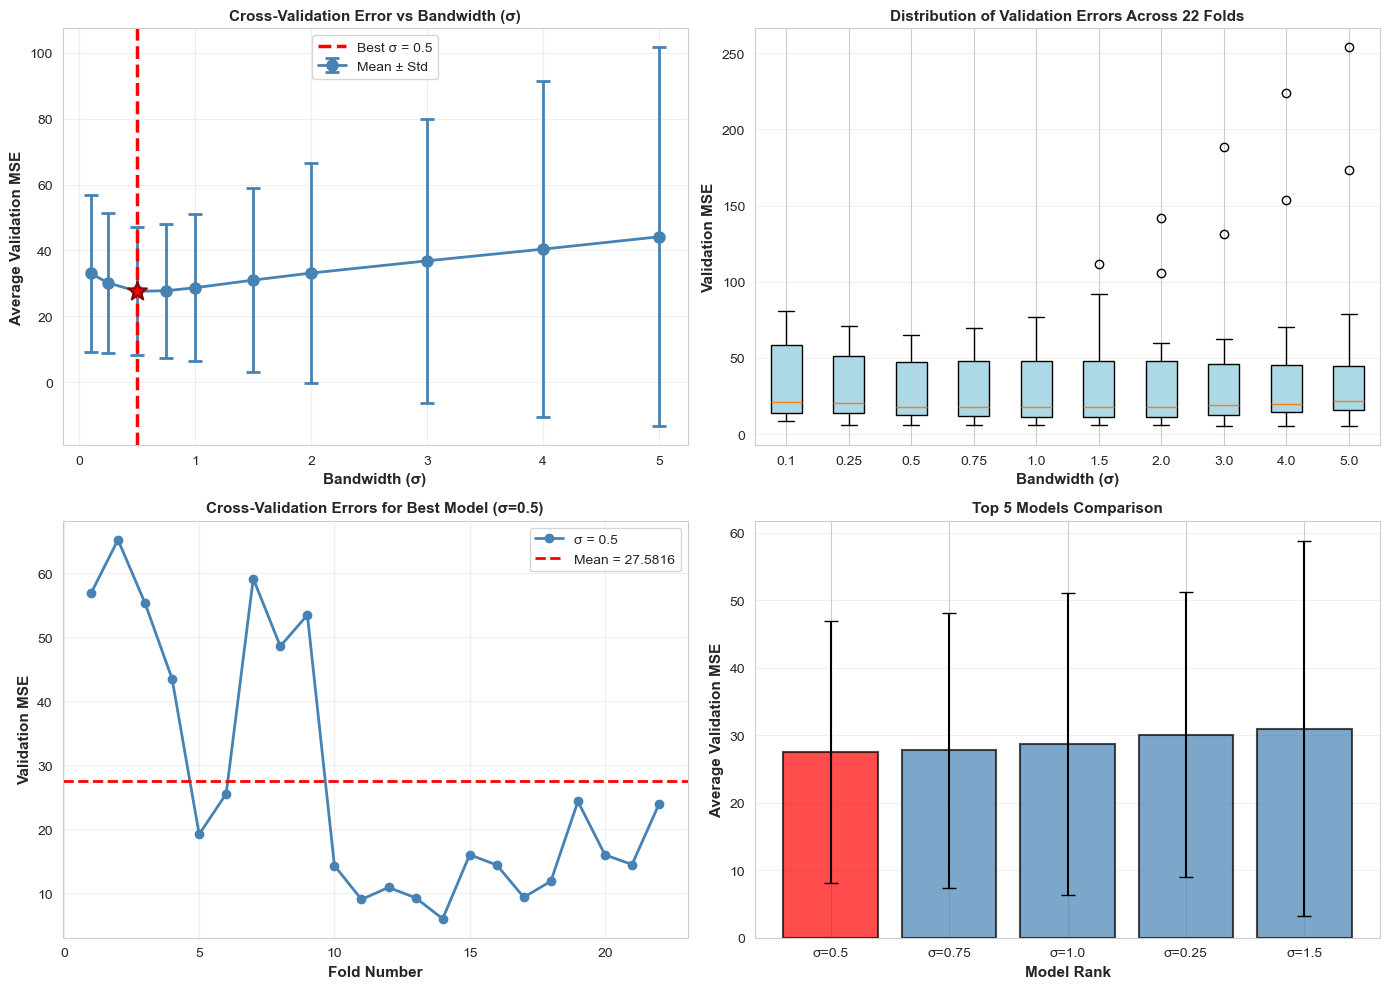

Visualization complete!


In [9]:
# Create comprehensive visualization of validation results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Average validation error vs sigma with error bars
sigma_list = list(avg_validation_errors.keys())
errors = list(avg_validation_errors.values())
stds = list(std_validation_errors.values())

axes[0, 0].errorbar(sigma_list, errors, yerr=stds, marker='o', linestyle='-', linewidth=2, 
                  markersize=8, capsize=5, capthick=2, color='steelblue', label='Mean ± Std')
axes[0, 0].axvline(x=best_sigma, color='red', linestyle='--', linewidth=2.5, label=f'Best σ = {best_sigma}')
axes[0, 0].scatter([best_sigma], [best_error], color='red', s=200, marker='*', zorder=5, edgecolors='darkred', linewidth=1.5)
axes[0, 0].set_xlabel('Bandwidth (σ)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Average Validation MSE', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Cross-Validation Error vs Bandwidth (σ)', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=10, loc='best')

# Plot 2: Distribution of errors across folds (box plot)
bp = axes[0, 1].boxplot([validation_errors[s] for s in sigma_list], labels=[f'{s}' for s in sigma_list], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[0, 1].set_xlabel('Bandwidth (σ)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Validation MSE', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Distribution of Validation Errors Across 22 Folds', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: All individual fold errors for best sigma
axes[1, 0].plot(range(1, n_strata + 1), validation_errors[best_sigma], marker='o', linestyle='-', 
                color='steelblue', linewidth=2, markersize=6, label=f'σ = {best_sigma}')
axes[1, 0].axhline(y=best_error, color='red', linestyle='--', linewidth=2, label=f'Mean = {best_error:.4f}')
axes[1, 0].set_xlabel('Fold Number', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Validation MSE', fontsize=11, fontweight='bold')
axes[1, 0].set_title(f'Cross-Validation Errors for Best Model (σ={best_sigma})', fontsize=11, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=10)

# Plot 4: Comparison of top models
sorted_models = sorted(avg_validation_errors.items(), key=lambda x: x[1])
top_sigma_vals = [s for s, _ in sorted_models[:5]]
top_errors = [avg_validation_errors[s] for s in top_sigma_vals]
top_stds = [std_validation_errors[s] for s in top_sigma_vals]
colors = ['red' if s == best_sigma else 'steelblue' for s in top_sigma_vals]

bars = axes[1, 1].bar(range(len(top_sigma_vals)), top_errors, yerr=top_stds, capsize=5, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 1].set_xlabel('Model Rank', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Average Validation MSE', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Top 5 Models Comparison', fontsize=11, fontweight='bold')
axes[1, 1].set_xticks(range(len(top_sigma_vals)))
axes[1, 1].set_xticklabels([f'σ={s}' for s in top_sigma_vals])
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Visualization complete!")

## Step 7: Fit the Best Model and Visualize

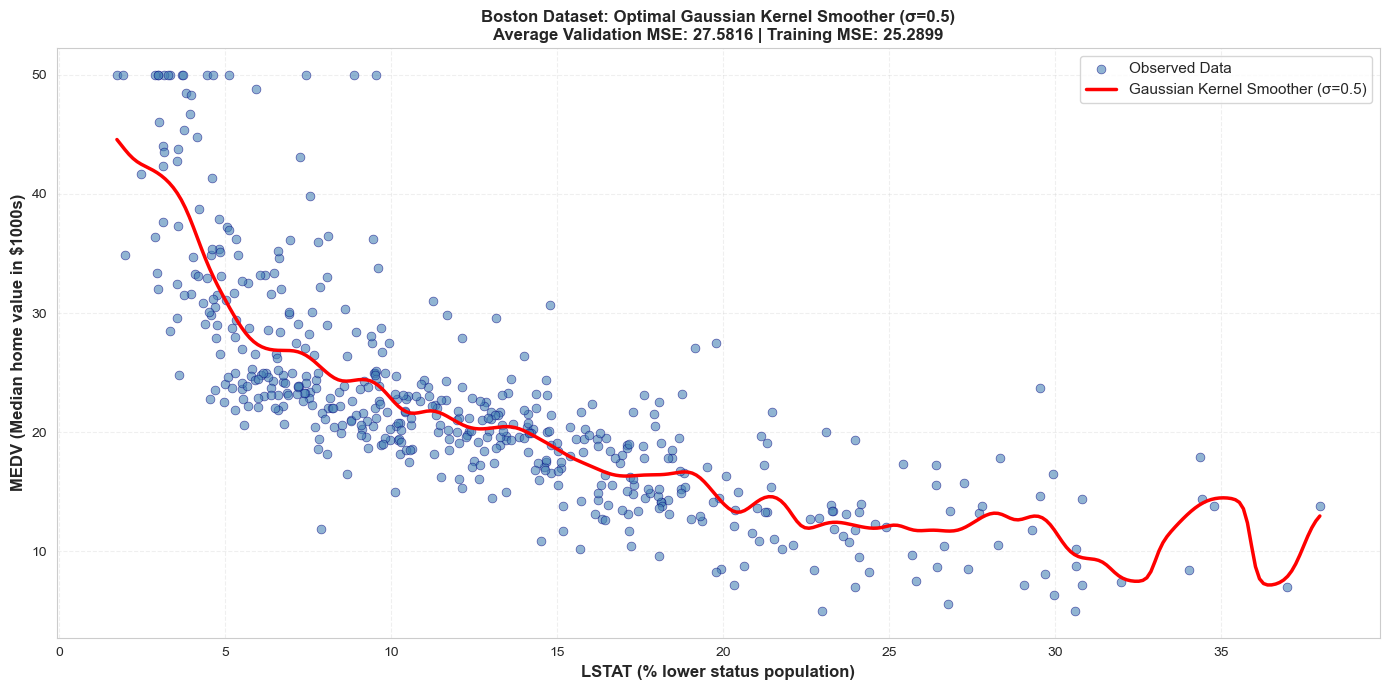


Best Model Fitted Successfully!
Bandwidth parameter (σ): 0.5
Training MSE: 25.2899
Average Validation MSE: 27.5816


In [10]:
# Fit the best model on the entire dataset
Y_pred_best = kernel_smoother_gaussian(X_full, Y_full, X_full, best_sigma)

# Create a fine grid for smooth visualization
X_grid = np.linspace(X_full.min(), X_full.max(), 300)
Y_grid_pred = kernel_smoother_gaussian(X_full, Y_full, X_grid, best_sigma)

# Calculate training MSE for best model
train_mse_best = compute_mse(Y_full, Y_pred_best)

# Plot the fitted model
fig, ax = plt.subplots(figsize=(14, 7))

# Scatter plot of actual data
ax.scatter(X_full, Y_full, alpha=0.6, s=40, color='steelblue', edgecolors='navy', linewidth=0.5, label='Observed Data')

# Plot Gaussian kernel smoother fit
ax.plot(X_grid, Y_grid_pred, color='red', linewidth=2.5, label=f'Gaussian Kernel Smoother (σ={best_sigma})', zorder=4)

ax.set_xlabel('LSTAT (% lower status population)', fontsize=12, fontweight='bold')
ax.set_ylabel('MEDV (Median home value in $1000s)', fontsize=12, fontweight='bold')
ax.set_title(f'Boston Dataset: Optimal Gaussian Kernel Smoother (σ={best_sigma})\n'
            f'Average Validation MSE: {best_error:.4f} | Training MSE: {train_mse_best:.4f}',
            fontsize=12, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print(f"\nBest Model Fitted Successfully!")
print(f"Bandwidth parameter (σ): {best_sigma}")
print(f"Training MSE: {train_mse_best:.4f}")
print(f"Average Validation MSE: {best_error:.4f}")

## Step 8: Visualize Different Bandwidths

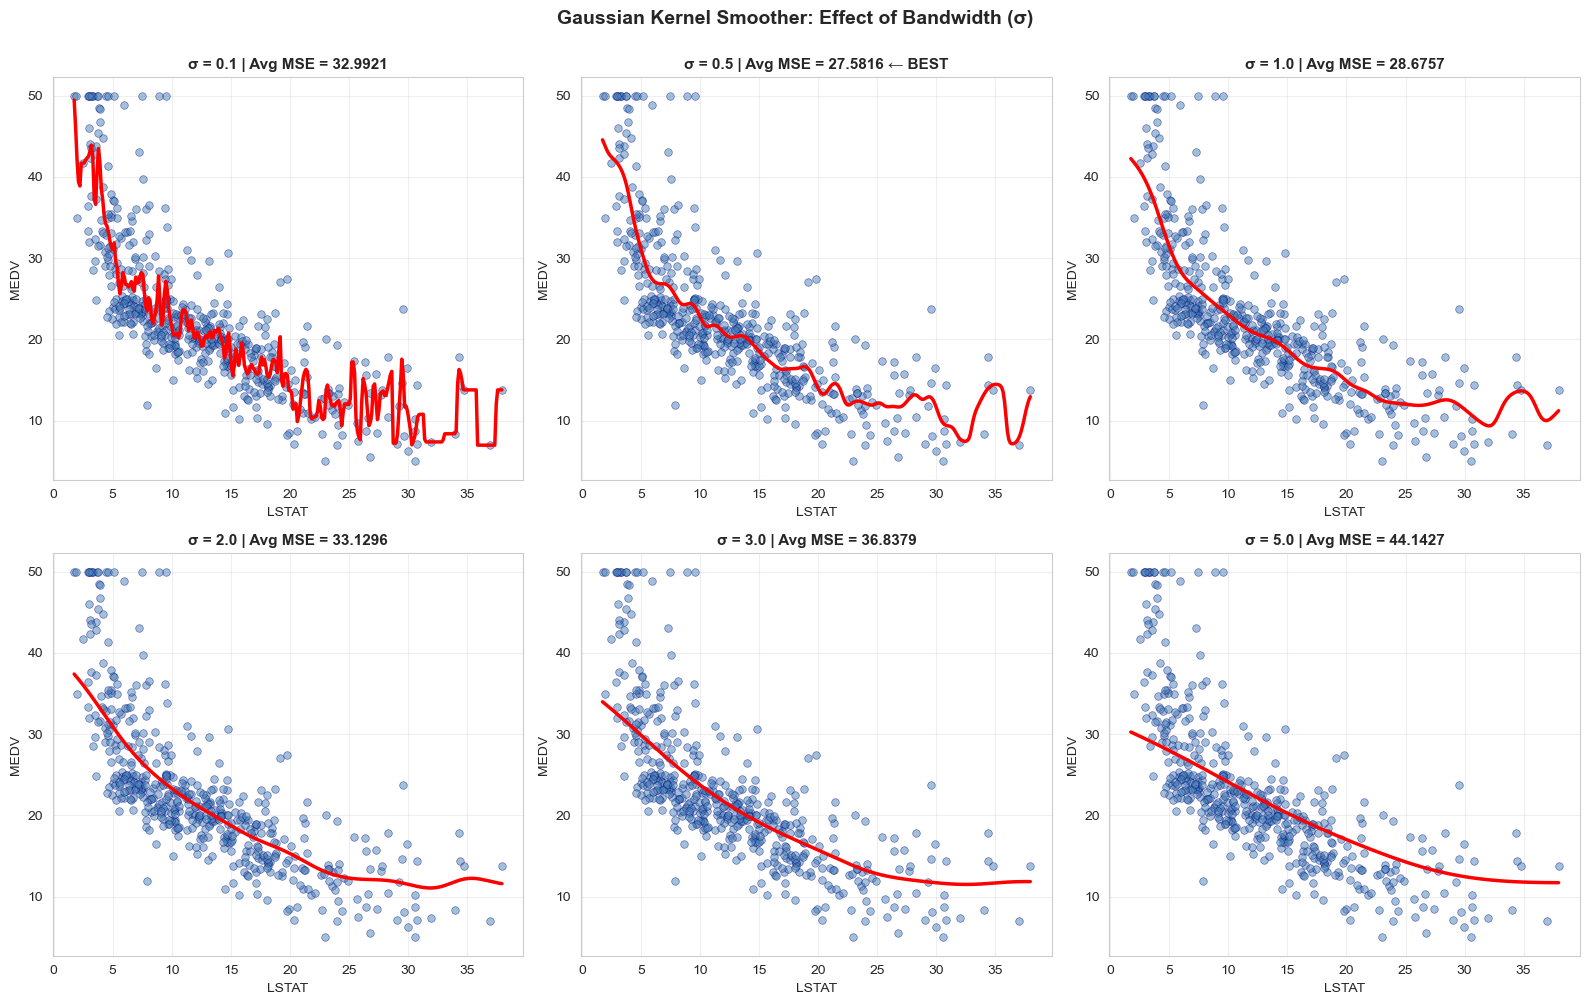


Visualization of different bandwidths complete!

Observations:
  • Small σ (0.1): Very wiggly fit, captures noise (high variance)
  • Medium σ (1.0): Balanced fit, good generalization
  • Large σ (5.0): Very smooth, may miss patterns (high bias)


In [11]:
# Create visualizations for different sigma values
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

# Select representative sigma values to visualize
sigmas_to_plot = [0.1, 0.5, 1.0, 2.0, 3.0, 5.0]

for idx, sigma in enumerate(sigmas_to_plot):
    # Fit model with this sigma
    Y_pred_grid = kernel_smoother_gaussian(X_full, Y_full, X_grid, sigma)
    
    # Plot
    axes[idx].scatter(X_full, Y_full, alpha=0.5, s=30, color='steelblue', edgecolors='navy', linewidth=0.5)
    axes[idx].plot(X_grid, Y_pred_grid, color='red', linewidth=2.5)
    
    avg_mse = avg_validation_errors[sigma]
    is_best = " ← BEST" if sigma == best_sigma else ""
    axes[idx].set_title(f'σ = {sigma} | Avg MSE = {avg_mse:.4f}{is_best}', fontweight='bold', fontsize=11)
    axes[idx].set_xlabel('LSTAT', fontsize=10)
    axes[idx].set_ylabel('MEDV', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Gaussian Kernel Smoother: Effect of Bandwidth (σ)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\nVisualization of different bandwidths complete!")
print("\nObservations:")
print(f"  • Small σ (0.1): Very wiggly fit, captures noise (high variance)")
print(f"  • Medium σ (1.0): Balanced fit, good generalization")
print(f"  • Large σ (5.0): Very smooth, may miss patterns (high bias)")

## Step 9: Detailed Summary and Conclusions

In [12]:
print("\n" + "="*90)
print("SUMMARY AND CONCLUSIONS")
print("="*90)

print(f"\n📊 DATASET INFORMATION:")
print(f"-" * 90)
print(f"Dataset: Boston Housing Dataset")
print(f"Total observations: {len(X_full)}")
print(f"Response Variable (Y): MEDV (Median home value in $1000s)")
print(f"  Range: [{Y_full.min():.2f}, {Y_full.max():.2f}]")
print(f"  Mean: {Y_full.mean():.2f}, Std Dev: {Y_full.std():.2f}")
print(f"Predictor Variable (X): LSTAT (% lower status population)")
print(f"  Range: [{X_full.min():.2f}, {X_full.max():.2f}]")
print(f"  Mean: {X_full.mean():.2f}, Std Dev: {X_full.std():.2f}")

print(f"\n🔀 CROSS-VALIDATION STRATEGY:")
print(f"-" * 90)
print(f"Method: 22-Fold Stratified Cross-Validation")
print(f"  - Number of strata: 22")
print(f"  - Stratum size: ~{stratum_size} observations each")
print(f"  - Stratification: Based on sorted LSTAT values")
print(f"  - Each fold uses 1 stratum as test, 21 strata as training")

print(f"\n🔍 MODEL SELECTION:")
print(f"-" * 90)
print(f"Algorithm: Gaussian Kernel Smoother (Nadaraya-Watson Estimator)")
print(f"Sigma values tested: {sigma_values}")
print(f"Selection criterion: Minimum average validation MSE across 22 folds")

print(f"\n🏆 BEST MODEL:")
print(f"-" * 90)
print(f"Optimal bandwidth (σ): {best_sigma}")
print(f"Average Validation MSE: {best_error:.4f}")
print(f"Standard Deviation: {std_validation_errors[best_sigma]:.4f}")
print(f"Min Validation MSE: {min_validation_errors[best_sigma]:.4f}")
print(f"Max Validation MSE: {max_validation_errors[best_sigma]:.4f}")
print(f"Training MSE: {train_mse_best:.4f}")

print(f"\n📈 COMPARISON WITH OTHER MODELS:")
print(f"-" * 90)
sorted_models = sorted(avg_validation_errors.items(), key=lambda x: x[1])
for rank, (sigma, error) in enumerate(sorted_models[:5], 1):
    std = std_validation_errors[sigma]
    marker = " ← BEST" if sigma == best_sigma else ""
    print(f"  {rank}. σ = {sigma:4.2f}: Avg MSE = {error:.4f} ± {std:.4f}{marker}")

print(f"\n💡 GAUSSIAN KERNEL SMOOTHER:")
print(f"-" * 90)
print(f"The Gaussian kernel smoother (Nadaraya-Watson estimator) works as follows:")
print(f"\n  Prediction for point x: f̂(x) = Σ[K((x-xᵢ)/σ) * yᵢ] / Σ[K((x-xᵢ)/σ)]")
print(f"  where K(u) = exp(-u²/2) is the Gaussian kernel")
print(f"\nBandwidth (σ) effects:")
print(f"  • Small σ → Narrow kernel → Local estimates → Wiggly fit (high variance)")
print(f"  • Large σ → Wide kernel → Global estimates → Smooth fit (high bias)")
print(f"  • Optimal σ → Balance between bias and variance")
print(f"\nWith σ = {best_sigma}:")
print(f"  - Using Gaussian weights centered at test points")
print(f"  - Bandwidth provides optimal smoothing")
print(f"  - Achieved minimum cross-validation error among tested values")

print(f"\n📋 METHODOLOGY:")
print(f"-" * 90)
print(f"  1. Divide 506 observations into 22 strata (~23 observations per stratum)")
print(f"  2. Apply leave-one-stratum-out cross-validation")
print(f"  3. For each fold and each σ value:")
print(f"     a) Train Gaussian kernel smoother on 21 strata")
print(f"     b) Evaluate on held-out stratum")
print(f"     c) Record validation MSE")
print(f"  4. Compute average validation MSE for each σ across 22 folds")
print(f"  5. Select σ with minimum average validation MSE")
print(f"  6. Fit final model on full dataset using best σ")

print(f"\n🎯 KEY FINDINGS:")
print(f"-" * 90)

# Compute correlation for reference
correlation = np.corrcoef(X_full, Y_full)[0, 1]
print(f"Pearson correlation (LSTAT, MEDV): {correlation:.4f}")
print(f"  → Strong negative relationship: Higher % lower status → Lower home values")

if best_sigma <= 0.5:
    complexity = "flexible, capturing local variations with minimal smoothing"
elif best_sigma <= 2.0:
    complexity = "balanced, providing moderate smoothing with good generalization"
else:
    complexity = "heavily smoothed, capturing global trends with less detail"

print(f"\nOptimal σ = {best_sigma} suggests the model is:")
print(f"  → {complexity}")
print(f"  → Avoiding both overfitting (small σ) and underfitting (large σ)")

print(f"\n" + "="*90)
print(f"✓ Analysis Complete!")
print("="*90)


SUMMARY AND CONCLUSIONS

📊 DATASET INFORMATION:
------------------------------------------------------------------------------------------
Dataset: Boston Housing Dataset
Total observations: 506
Response Variable (Y): MEDV (Median home value in $1000s)
  Range: [5.00, 50.00]
  Mean: 22.53, Std Dev: 9.19
Predictor Variable (X): LSTAT (% lower status population)
  Range: [1.73, 37.97]
  Mean: 12.65, Std Dev: 7.13

🔀 CROSS-VALIDATION STRATEGY:
------------------------------------------------------------------------------------------
Method: 22-Fold Stratified Cross-Validation
  - Number of strata: 22
  - Stratum size: ~23 observations each
  - Stratification: Based on sorted LSTAT values
  - Each fold uses 1 stratum as test, 21 strata as training

🔍 MODEL SELECTION:
------------------------------------------------------------------------------------------
Algorithm: Gaussian Kernel Smoother (Nadaraya-Watson Estimator)
Sigma values tested: [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5